In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
# --- สำหรับจัดการ PDF ---
!pip install PyMuPDF

# --- สำหรับวัดผล (CER) ---
!pip install jiwer

# --- (ถ้าคุณใช้ทางเลือก A: Tesseract) ---
# 1. ติดตั้ง Python wrapper
!pip install pytesseract

# 2. (สำคัญมาก!) ติดตั้ง Tesseract Engine และ "ภาษาไทย" ลงในระบบของ Colab
!sudo apt install tesseract-ocr
!sudo apt install tesseract-ocr-tha

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.1/24.1 MB 104.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 112.0 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  tesseract-ocr-tha
0 upgraded, 1 newly installed, 0 to remove and 41 not upgraded.
Need to get 899 kB of archives.
After this operation, 1,087 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr-tha all 1:4.00~git30-7274cfa-1.1 [899 kB]
Fetched 899 kB in 3s (336 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be u

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator
import cv2
import numpy as np
from PIL import Image, ImageOps
import fitz  # PyMuPDF
import pytesseract
import jiwer
import os
import glob
import matplotlib.pyplot as plt

In [ ]:
PROJECT_DIR = '/content/drive/MyDrive/Colab Notebooks/Project_OCR'
OUTPUT_DIR = os.path.join(PROJECT_DIR, 'Dataset_CleanData' )
PDF_INPUT_DIR = os.path.join(PROJECT_DIR, 'Dataset_RawData')

if not os.path.exists(PROJECT_DIR):
    print(f"[ERROR] ไม่พบโฟลเดอร์โปรเจค: {PROJECT_DIR}")
    print("กรุณาตรวจสอบว่า Mount Drive สำเร็จและสร้างโฟลเดอร์แล้ว")

if not os.path.exists(PDF_INPUT_DIR):
    print(f"[WARNING] ไม่พบโฟลเดอร์ Input: {PDF_INPUT_DIR}")

if not os.path.exists(OUTPUT_DIR):
    print(f"[INFO] กำลังสร้างโฟลเดอร์ Output: {OUTPUT_DIR}")
    os.makedirs(OUTPUT_DIR, exist_ok=True)

pdf_file_paths = glob.glob(os.path.join(PDF_INPUT_DIR, "*.pdf"))
print(f"\n[INFO] ตรวจพบไฟล์ PDF ทั้งหมด: {len(pdf_file_paths)} ไฟล์")
print(f"      จากโฟลเดอร์: {PDF_INPUT_DIR}")


[INFO] ตรวจพบไฟล์ PDF ทั้งหมด: 7 ไฟล์
      จากโฟลเดอร์: /content/drive/MyDrive/Colab Notebooks/Project_OCR/Dataset_RawData


In [ ]:
# --- (โค้ดใน Cell 4 หรือ 5) ---

# pdf_file_paths คือตัวแปร List ที่เราสร้างไว้ใน Cell 3
for pdf_path in pdf_file_paths:


    # [CHECK] 1. สร้างชื่อไฟล์ผลลัพธ์ (ของหน้าแรก) ที่เราคาดหวัง
    pdf_name = os.path.basename(pdf_path).replace('.pdf', '')
    expected_first_page_name = f"{pdf_name}_page_0.png"
    expected_output_path = os.path.join(OUTPUT_DIR, expected_first_page_name)

    # [CHECK] 2. ตรวจสอบว่าไฟล์หน้าแรกนี้มีอยู่จริงหรือไม่
    if os.path.exists(expected_output_path):
        print(f"\n[INFO] ข้ามไฟล์: {pdf_name}.pdf (ไฟล์ที่ Clean แล้วมีอยู่)")
        continue  # <-- นี่คือคำสั่งสำคัญ! ข้ามไปไฟล์ PDF ถัดไป

    # 3. [PROCESS] ถ้าไฟล์ยังไม่มี (if block = False) ก็เริ่มประมวลผลตามปกติ
    try:
        doc = fitz.open(pdf_path)
        print(f"\n[INFO] กำลังประมวลผลไฟล์ใหม่: {pdf_name}.pdf (มี {doc.page_count} หน้า)")

        # 4. วนลูปอ่านทีละหน้าใน PDF
        for page_num in range(doc.page_count):
            page = doc.load_page(page_num)
            pix = page.get_pixmap(dpi=300)

            # 5. แปลง Pixmap (ของ PyMuPDF) เป็น Numpy Array (ของ OpenCV)
            img_data = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, pix.n)

            if pix.n == 4:
                img_cv = cv2.cvtColor(img_data, cv2.COLOR_BGRA2BGR)
            else:
                img_cv = img_data

            # 6. ทำ Image Pre-processing ด้วย OpenCV
            gray = cv2.cvtColor(img_cv, cv2.COLOR_BGR2GRAY)

            # 7. ทำ Binarization (ภาพขาว-ดำ)
            # (ปรับปรุง) เราจะใช้ THRESH_BINARY (ตัวอักษรดำ 0, พื้นขาว 255)
            # เพราะ Pytesseract (ทางเลือก A) จะชอบแบบนี้มากกว่าครับ
            (thresh, binary_img) = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)



            # 8. บันทึกรูปภาพที่ "สะอาด" แล้ว
            output_filename = f"{pdf_name}_page_{page_num}.png"
            output_path = os.path.join(OUTPUT_DIR, output_filename)

            try:
                cv2.imwrite(output_path, binary_img)
            except Exception as e:
                print(f"    [ERROR] ไม่สามารถบันทึกภาพ {output_filename}: {e}")

        doc.close()
        print(f"[INFO] ประมวลผล {pdf_name}.pdf เสร็จสิ้น")

    except Exception as e:
        print(f"[ERROR] ไม่สามารถเปิดหรือประมวลผลไฟล์ {pdf_path}: {e}")

print("\n---  ประมวลผล PDF ทั้งหมดเสร็จสิ้น ---")


[INFO] ข้ามไฟล์: 2. แบบฟอร์มคำสั่ง.pdf (ไฟล์ที่ Clean แล้วมีอยู่)

[INFO] ข้ามไฟล์: 2021110325e5357ef77b36f518f82b6263a9b9dd154011.pdf (ไฟล์ที่ Clean แล้วมีอยู่)

[INFO] ข้ามไฟล์: media (1).pdf (ไฟล์ที่ Clean แล้วมีอยู่)

[INFO] ข้ามไฟล์: media.pdf (ไฟล์ที่ Clean แล้วมีอยู่)

[INFO] ข้ามไฟล์: 83911.pdf (ไฟล์ที่ Clean แล้วมีอยู่)

[INFO] ข้ามไฟล์: ระเบียบกระทรวงการคลังว่าด้วยการเบิกค่าใช้จ่ายในการเดินทางไปราชการ-พ.ศ.-2565-ฉบับที่-3.pdf (ไฟล์ที่ Clean แล้วมีอยู่)

[INFO] ข้ามไฟล์: เอกสาร-8 (1).pdf (ไฟล์ที่ Clean แล้วมีอยู่)

---  ประมวลผล PDF ทั้งหมดเสร็จสิ้น ---


In [ ]:
#V1
"""

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import os

# --- 1. ตั้งค่า Path และ Parameter ---
DATASET_DIR = '/content/drive/MyDrive/Colab Notebooks/Project_OCR/Training_Data/Raw_thai_handwriting_data'

# [อัปเกรด!] ขนาด 64x64
IMG_HEIGHT = 64
IMG_WIDTH = 64
BATCH_SIZE = 32
EPOCHS = 100

# [แก้ไข!] สร้างเฉลยที่ถูกต้อง (บังคับลำดับ)
# นี่คือการบอก Keras ว่า:
# index 0 = folder '10' (เลข ๐)
# index 1 = folder '1' (เลข ๑)
# ...
CLASS_NAMES_IN_ORDER = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
print(f"กำลังบังคับลำดับ Class: {CLASS_NAMES_IN_ORDER}")

# --- 2. เตรียม Data Generators ---
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    validation_split=0.2
)

print("กำลังเตรียมข้อมูล Train Set (64x64)...")
train_generator = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH), # [อัปเกรด!]
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    class_mode='categorical',
    subset='training',
    classes=CLASS_NAMES_IN_ORDER # [แก้ไข!] บังคับให้ใช้ลำดับนี้
)

print("กำลังเตรียมข้อมูล Validation Set (64x64)...")
validation_generator = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH), # [อัปเกR!ด!]
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    class_mode='categorical',
    subset='validation',
    classes=CLASS_NAMES_IN_ORDER # [แก้ไข!] บังคับให้ใช้ลำดับนี้
)

# --- 3. [อัปเกรด!] สร้างโมเดล CNN ที่ "ลึกขึ้น" (Deeper VGG-style) ---
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                  input_shape=(IMG_HEIGHT, IMG_WIDTH, 1)),
    layers.MaxPooling2D((2, 2)), # -> 32x32
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)), # -> 16x16
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)), # -> 8x8
    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)), # -> 4x4
    layers.Flatten(), # (4 * 4 * 256 = 4096 features)
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax') # 10 classes (0-9)
])

optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)
model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

# --- 4. เริ่มเทรนโมเดล! ---
print("\n--- เริ่มต้นการเทรนโมเดล (Deep 64x64) ---")
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator
)

# --- 5. บันทึกโมเดลที่เทรนเสร็จแล้ว ---
# [อัปเกรด!] บันทึกเป็นชื่อใหม่ และใช้ .keras
MODEL_SAVE_PATH_64 = '/content/drive/MyDrive/Colab Notebooks/Project_OCR/thai_digit_model_64x64_V1.keras'
model.save(MODEL_SAVE_PATH_64)
print(f"\nบันทึกโมเดล (64x64) เรียบร้อยแล้วที่: {MODEL_SAVE_PATH_64}")
"""


'\n\nimport tensorflow as tf\nfrom tensorflow.keras import layers, models\nfrom tensorflow.keras.preprocessing.image import ImageDataGenerator\nimport matplotlib.pyplot as plt\nimport os\n\n# --- 1. ตั้งค่า Path และ Parameter ---\nDATASET_DIR = \'/content/drive/MyDrive/Colab Notebooks/Project_OCR/Training_Data/Raw_thai_handwriting_data\'\n\n# [อัปเกรด!] ขนาด 64x64\nIMG_HEIGHT = 64\nIMG_WIDTH = 64\nBATCH_SIZE = 32\nEPOCHS = 100\n\n# [แก้ไข!] สร้างเฉลยที่ถูกต้อง (บังคับลำดับ)\n# นี่คือการบอก Keras ว่า:\n# index 0 = folder \'10\' (เลข ๐)\n# index 1 = folder \'1\' (เลข ๑)\n# ...\nCLASS_NAMES_IN_ORDER = [\'0\', \'1\', \'2\', \'3\', \'4\', \'5\', \'6\', \'7\', \'8\', \'9\']\nprint(f"กำลังบังคับลำดับ Class: {CLASS_NAMES_IN_ORDER}")\n\n# --- 2. เตรียม Data Generators ---\ntrain_datagen = ImageDataGenerator(\n    rescale=1./255,\n    rotation_range=10,\n    width_shift_range=0.1,\n    height_shift_range=0.1,\n    zoom_range=0.1,\n    validation_split=0.2\n)\n\nprint("กำลังเตรียมข้อมูล Train Set

กำลังบังคับลำดับ Class: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
กำลังเตรียมข้อมูล Train Set (64x64) + Thickness Augmentation...
Found 2673 images belonging to 10 classes.
กำลังเตรียมข้อมูล Validation Set (64x64)...
Found 663 images belonging to 10 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,623,754 (6.19 MB)

 Trainable params: 1,623,754 (6.19 MB)

 Non-trainable params: 0 (0.00 B)


--- เริ่มต้นการเทรนโมเดล (Deep 64x64 + Thickness Augment) ---


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/200
84/84 ━━━━━━━━━━━━━━━━━━━━ 798s 9s/step - accuracy: 0.1007 - loss: 2.3008 - val_accuracy: 0.4027 - val_loss: 1.7443
Epoch 2/200
84/84 ━━━━━━━━━━━━━━━━━━━━ 15s 181ms/step - accuracy: 0.3698 - loss: 1.7901 - val_accuracy: 0.7195 - val_loss: 0.8581
Epoch 3/200
84/84 ━━━━━━━━━━━━━━━━━━━━ 15s 180ms/step - accuracy: 0.5979 - loss: 1.1637 - val_accuracy: 0.8718 - val_loss: 0.3756
Epoch 4/200
84/84 ━━━━━━━━━━━━━━━━━━━━ 15s 181ms/step - accuracy: 0.7338 - loss: 0.7590 - val_accuracy: 0.8673 - val_loss: 0.3352
Epoch 5/200
84/84 ━━━━━━━━━━━━━━━━━━━━ 16s 190ms/step - accuracy: 0.8091 - loss: 0.5767 - val_accuracy: 0.9231 - val_loss: 0.2338
Epoch 6/200
84/84 ━━━━━━━━━━━━━━━━━━━━ 15s 180ms/step - accuracy: 0.8392 - loss: 0.4527 - val_accuracy: 0.9336 - val_loss: 0.1603
Epoch 7/200
84/84 ━━━━━━━━━━━━━━━━━━━━ 15s 180ms/step - accuracy: 0.8868 - loss: 0.3370 - val_accuracy: 0.9517 - val_loss: 0.1423
Epoch 8/200
84/84 ━━━━━━━━━━━━━━━━━━━━ 15s 180ms/step - accuracy: 0.8937 - loss: 0.3069 - va

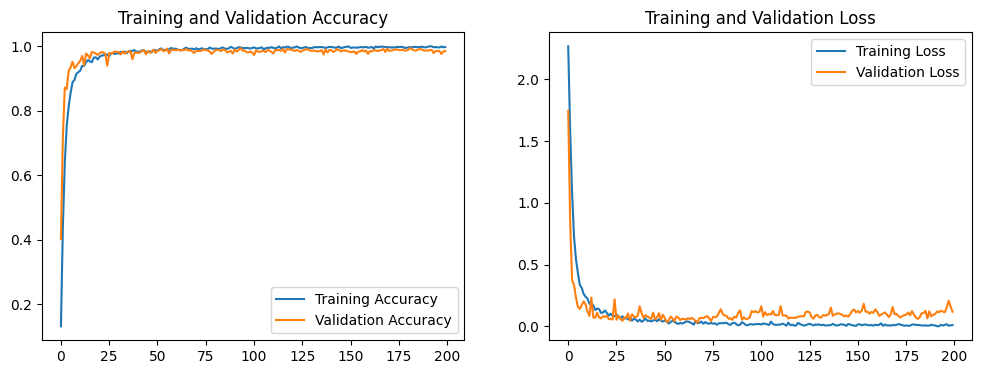

In [ ]:
#V2
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import os
import cv2      # [ใหม่!] ต้องใช้ OpenCV สำหรับปรับความหนาเส้น
import numpy as np # [ใหม่!] ใช้สำหรับการคำนวณสุ่ม

# --- 1. ตั้งค่า Path และ Parameter ---
DATASET_DIR = '/content/drive/MyDrive/Colab Notebooks/Project_OCR/Training_Data/Raw_thai_handwriting_data'

IMG_HEIGHT = 64
IMG_WIDTH = 64
BATCH_SIZE = 32
EPOCHS = 200

CLASS_NAMES_IN_ORDER = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
print(f"กำลังบังคับลำดับ Class: {CLASS_NAMES_IN_ORDER}")

# --- [ใหม่!] ฟังก์ชันสำหรับสุ่มปรับความหนาของเส้น (Thickness Augmentation) ---
def augment_thickness(img):
    """
    ฟังก์ชันนี้จะสุ่มปรับภาพให้เส้นหนาขึ้นหรือบางลง
    input: img (numpy array จาก Keras generator)
    """
    # สุ่มโอกาส 50% ที่จะปรับความหนา (ถ้าไม่โดนก็คืนค่าเดิม)
    if np.random.rand() < 0.5:
        return img

    # แปลงภาพเป็น format ที่ OpenCV เข้าใจ (ตัด dimension สีออกชั่วคราวถ้ามี)
    # img จาก flow_from_directory อาจจะเป็น float32 0-255 หรือ 0-1 ขึ้นอยู่กับตำแหน่งการ rescale
    # แต่ preprocessing_function ทำงาน *ก่อน* rescale ดังนั้นค่าจะเป็น 0-255

    # สร้าง Kernel สำหรับ Morphological Ops (ขนาด 2x2 หรือ 3x3)
    # ขนาด kernel ยิ่งใหญ่ เส้นยิ่งเปลี่ยนเยอะ (2x2 กำลังดีสำหรับ 64x64)
    kernel_size = np.random.choice([2, 3])
    kernel = np.ones((kernel_size, kernel_size), np.uint8)

    # สุ่มเลือกว่าจะทำให้ "หนา" หรือ "บาง"
    # หมายเหตุ: ผลลัพธ์ขึ้นอยู่กับว่าภาพเป็น "ตัวดำพื้นขาว" หรือ "ตัวขาวพื้นดำ"
    # แต่การสุ่มทั้ง Erode และ Dilate จะครอบคลุมทั้งสองกรณี
    decision = np.random.choice(['thicker', 'thinner'])

    if decision == 'thicker':
        # Erode: โดยปกติถ้าพื้นขาว(255) ตัวดำ(0) -> Erode จะกินพื้นที่สีขาว ทำให้สีดำขยาย (เส้นหนาขึ้น)
        img = cv2.erode(img, kernel, iterations=1)
    else:
        # Dilate: โดยปกติถ้าพื้นขาว(255) ตัวดำ(0) -> Dilate จะขยายพื้นที่สีขาว ทำให้สีดำหด (เส้นบางลง)
        img = cv2.dilate(img, kernel, iterations=1)

    # เนื่องจาก erode/dilate ของ cv2 จะลด dimension ของ channel ออก
    # เราต้อง reshape กลับให้เป็น (64, 64, 1) เพื่อให้ Keras เข้าใจ
    if len(img.shape) == 2:
        img = img.reshape(img.shape[0], img.shape[1], 1)

    return img

# --- 2. เตรียม Data Generators ---
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    preprocessing_function=augment_thickness, # [สำคัญ!] ใส่ฟังก์ชันปรับความหนาที่นี่
    validation_split=0.2
)

# สำหรับ Validation ไม่ต้องปรับความหนาแบบสุ่ม (เพื่อให้ผลวัดนิ่ง)
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

print("กำลังเตรียมข้อมูล Train Set (64x64) + Thickness Augmentation...")
train_generator = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    class_mode='categorical',
    subset='training',
    classes=CLASS_NAMES_IN_ORDER
)

print("กำลังเตรียมข้อมูล Validation Set (64x64)...")
# ใช้ val_datagen แยกต่างหากเพื่อไม่ให้ validation set โดนปรับเส้น (optional แต่แนะนำ)
validation_generator = val_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    class_mode='categorical',
    subset='validation',
    classes=CLASS_NAMES_IN_ORDER
)

# --- 3. สร้างโมเดล CNN (Deeper VGG-style) ---
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(IMG_HEIGHT, IMG_WIDTH, 1)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)
model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# --- 4. เริ่มเทรนโมเดล! ---
print("\n--- เริ่มต้นการเทรนโมเดล (Deep 64x64 + Thickness Augment) ---")
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator
)

# --- 5. บันทึกโมเดล ---
MODEL_SAVE_PATH_64_THICK = '/content/drive/MyDrive/Colab Notebooks/Project_OCR/thai_digit_model_64x64_Thickness_V2.keras'
save_dir = os.path.dirname(MODEL_SAVE_PATH_64_THICK)
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

model.save(MODEL_SAVE_PATH_64_THICK)
print(f"\nบันทึกโมเดล (รองรับเส้นหนา/บาง) เรียบร้อยแล้วที่: {MODEL_SAVE_PATH_64_THICK}")

def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.show()

try:
    plot_history(history)
except Exception as e:
    print(f"ไม่สามารถแสดงกราฟได้: {e}")


--- เริ่มต้น Phase 3: การทดสอบโมเดล (64x64) ---
กำลังโหลดโมเดลจาก: /content/drive/MyDrive/Colab Notebooks/Project_OCR/thai_digit_model_64x64_Thickness_V2.keras
โหลดโมเดลสำเร็จ!
กำลังโหลดรูปภาพทดสอบ: /content/drive/MyDrive/Colab Notebooks/Project_OCR/Screenshot 2025-11-13 200339.png
เตรียมรูปภาพสำเร็จ (Shape: (1, 64, 64, 1))
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

--- ผลการทำนาย ---
โมเดลคิดว่าเป็นเลข: ๙
ความมั่นใจ: 99.98 %


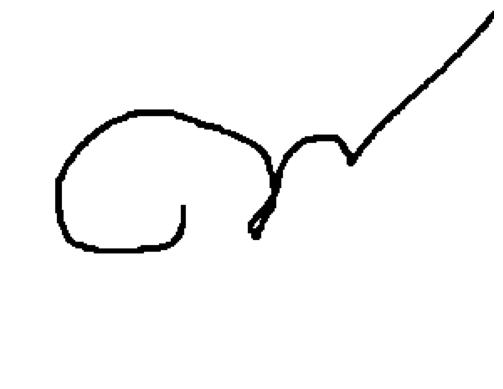

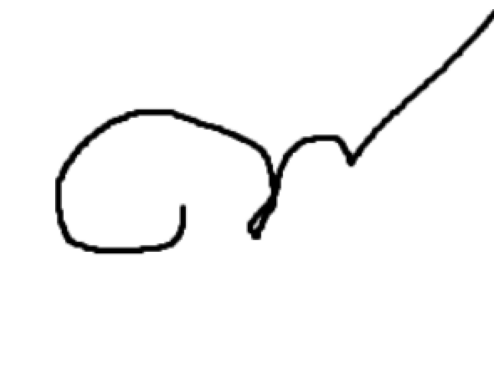

In [ ]:
# ==============================================================================
# Phase 3: Inference (เวอร์ชันอัปเกรด 64x64)
# [แก้ไข] - ลบ Adaptive Thresholding ออกตามคำขอ
# ==============================================================================

import tensorflow as tf
from tensorflow.keras.models import load_model
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

print("\n--- เริ่มต้น Phase 3: การทดสอบโมเดล (64x64) ---")

# --- 1. ตั้งค่า Path ---
PROJECT_DIR = '/content/drive/MyDrive/Colab Notebooks/Project_OCR'

# [ถูกต้อง!] โหลดโมเดล 64x64
MODEL_SAVE_PATH = os.path.join(PROJECT_DIR, 'thai_digit_model_64x64_Thickness_V2.keras')

TEST_IMAGE_PATH = os.path.join(PROJECT_DIR, 'Screenshot 2025-11-13 200339.png')

# [ถูกต้อง!] ตั้งค่าขนาดให้ตรงกับโมเดล
IMG_HEIGHT = 64
IMG_WIDTH = 64

# --- 2. โหลดโมเดลที่เทรนไว้ ---
print(f"กำลังโหลดโมเดลจาก: {MODEL_SAVE_PATH}")
try:
    model = load_model(MODEL_SAVE_PATH)
    print("โหลดโมเดลสำเร็จ!")
except Exception as e:
    print(f"[ERROR] ไม่สามารถโหลดโมเดลได้: {e}")
    raise e

# --- 3. [หัวใจสำคัญ] โหลดและเตรียมรูปภาพ (Preprocessing ด้วย OpenCV) ---
print(f"กำลังโหลดรูปภาพทดสอบ: {TEST_IMAGE_PATH}")
try:
    # 3.1 โหลดภาพด้วย OpenCV
    img = cv2.imread(TEST_IMAGE_PATH)
    if img is None:
        raise FileNotFoundError(f"ไม่สามารถเปิดไฟล์ภาพได้ที่: {TEST_IMAGE_PATH}")

    # 3.2 แปลงเป็น Grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 3.3 [!!! ลบออกตามคำขอ !!!] - Adaptive Thresholding
    # (โค้ดนี้ถูกปิดการใช้งาน)
    # binary_img = cv2.adaptiveThreshold(
    #     gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    #     cv2.THRESH_BINARY, 11, 2
    # )

    # 3.3 [ใหม่!] - ใช้ Global Thresholding (แบบธรรมดา)
    # [คำเตือน!] วิธีนี้จะทำงานได้ก็ต่อเมื่อภาพทดสอบ "สะอาด" มากๆ
    # (ตัวดำสนิท พื้นขาวสนิท) ถ้ามีพิกเซลสีเทาปน โมเดลจะทายผิด
    # เราใช้ THRESH_BINARY_INV เพื่อให้ "ตัวดำ" -> กลายเป็น "สีขาว (255)"
    # และ "พื้นขาว" -> กลายเป็น "สีดำ (0)"
    # (ขออภัยครับ โมเดลเราอาจจะเทรนแบบ Invert - ลองแบบนี้ก่อน)
    # _ , binary_img = cv2.threshold(gray, 128, 255, cv2.THRESH_BINARY_INV)

    # [แก้ไข] - เอากลับเป็นแบบ "ตัวดำ พื้นขาว" (ที่โมเดลเทรน)
    _ , binary_img = cv2.threshold(gray, 128, 255, cv2.THRESH_BINARY)

    # 3.4 ย่อขนาดภาพ (Resize)
    resized_img = cv2.resize(binary_img, (IMG_WIDTH, IMG_HEIGHT), interpolation=cv2.INTER_AREA)

    # 3.5 Rescale 0-255 -> 0-1
    img_array = resized_img / 255.0

    # 3.6 เพิ่มมิติ [1, 64, 64, 1]
    img_array_final = np.expand_dims(img_array, axis=(0, -1))

    print(f"เตรียมรูปภาพสำเร็จ (Shape: {img_array_final.shape})")

except FileNotFoundError:
    print(f"[ERROR] ไม่พบไฟล์ทดสอบ: {TEST_IMAGE_PATH}")
    raise FileNotFoundError()
except Exception as e:
    print(f"[ERROR] เกิดปัญหาตอนเตรียมรูปภาพ: {e}")
    raise e

# --- 4. ทำนายผล (Prediction) ---
prediction = model.predict(img_array_final)

# --- 5. แปลผลลัพธ์ ---
predicted_class_index = np.argmax(prediction[0])
confidence = np.max(prediction[0]) * 100

class_labels = ['๐', '๑', '๒', '๓', '๔', '๕', '๖', '๗', '๘', '๙']
predicted_digit_char = class_labels[predicted_class_index]

print("\n--- ผลการทำนาย ---")
print(f"โมเดลคิดว่าเป็นเลข: {predicted_digit_char}")
print(f"ความมั่นใจ: {confidence:.2f} %")

# --- 6. แสดงภาพผลลัพธ์ ---
# แสดงภาพ *หลัง* จากทำ Binarization แล้ว (ภาพที่โมเดลเห็นจริงๆ)
plt.imshow(binary_img, cmap='gray')
plt.axis('off')
plt.show()

# แสดงภาพต้นฉบับ
display_img_original = cv2.imread(TEST_IMAGE_PATH)
plt.imshow(cv2.cvtColor(display_img_original, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

--- เริ่มต้นระบบ Full Page OCR ---
กำลังโหลดโมเดล: /content/drive/MyDrive/Colab Notebooks/Project_OCR/thai_digit_model_64x64.keras
โหลดโมเดลสำเร็จ!
เจอวัตถุทั้งหมด: 1318 ชิ้น

--- ผลลัพธ์รวม ---
๗๘๘


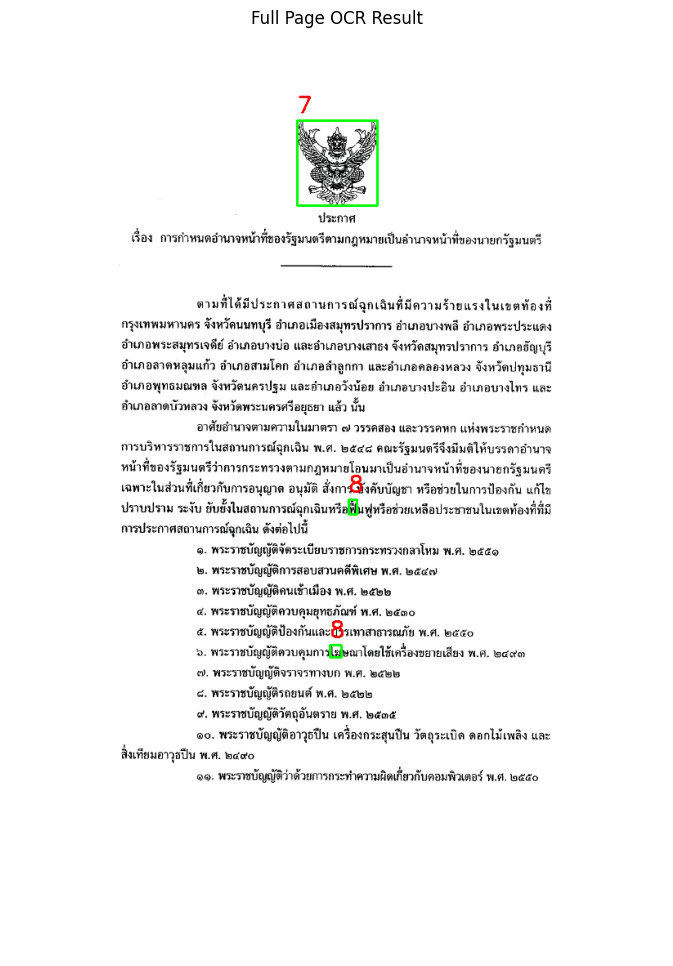

In [ ]:
# ==============================================================================
# Phase 4: Full Page OCR (Detection + Recognition)
# ==============================================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
import os

print("--- เริ่มต้นระบบ Full Page OCR ---")

# --- 1. ตั้งค่า Path ---
PROJECT_DIR = '/content/drive/MyDrive/Colab Notebooks/Project_OCR'
MODEL_PATH = os.path.join(PROJECT_DIR, 'thai_digit_model_64x64.keras')

# [ใส่รูปเอกสารทั้งหน้าของคุณที่นี่!]
FULL_PAGE_IMAGE_PATH = os.path.join(PROJECT_DIR, '/content/drive/MyDrive/Colab Notebooks/Project_OCR/bill1.png')

# ขนาดที่โมเดลต้องการ
IMG_HEIGHT = 64
IMG_WIDTH = 64

# --- 2. โหลดโมเดล ---
print(f"กำลังโหลดโมเดล: {MODEL_PATH}")
try:
    model = load_model(MODEL_PATH)
    print("โหลดโมเดลสำเร็จ!")
except:
    print("หาโมเดลไม่เจอ! กรุณารัน Phase 2 เพื่อสร้างโมเดลก่อน")
    exit()

# --- 3. ฟังก์ชันเตรียมภาพ (เหมือน Phase 3) ---
def preprocess_digit(img_crop):
    # แปลงเป็นขาวดำ
    if len(img_crop.shape) == 3:
        gray = cv2.cvtColor(img_crop, cv2.COLOR_BGR2GRAY)
    else:
        gray = img_crop

    # ทำ Threshold (ตัวดำ พื้นขาว)
    _, binary = cv2.threshold(gray, 128, 255, cv2.THRESH_BINARY)

    # Resize เป็น 64x64
    resized = cv2.resize(binary, (IMG_WIDTH, IMG_HEIGHT), interpolation=cv2.INTER_AREA)

    # Normalize 0-1
    normalized = resized / 255.0

    # เพิ่มมิติ [1, 64, 64, 1]
    return np.expand_dims(normalized, axis=(0, -1))

# --- 4. กระบวนการหลัก (Main Pipeline) ---

# 4.1 โหลดภาพทั้งหน้า
image = cv2.imread(FULL_PAGE_IMAGE_PATH)
if image is None:
    print(f"อ่านไฟล์ภาพไม่ได้: {FULL_PAGE_IMAGE_PATH}")
    exit()

# สำรองภาพไว้แสดงผล
output_image = image.copy()

# 4.2 แปลงเป็น Grayscale เพื่อหา Contours
gray_page = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# 4.3 ทำ Binarization (สำคัญมากสำหรับการหาขอบ)
# ใช้ adaptiveThreshold เพื่อจัดการกับแสงเงาในหน้ากระดาษได้ดีกว่า
binary_page = cv2.adaptiveThreshold(
    gray_page, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV, 11, 2 # ใช้ INV เพื่อให้ตัวหนังสือเป็นสีขาว (OpenCV ชอบหาวัตถุสีขาวบนพื้นดำ)
)

# 4.4 ค้นหา Contours (เส้นขอบของตัวอักษร)
# EXTERNAL = หาเฉพาะกรอบนอกสุด (ไม่เอาไส้ในเลข ๐ หรือ ๔)
contours, _ = cv2.findContours(binary_page, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

print(f"เจอวัตถุทั้งหมด: {len(contours)} ชิ้น")

# เรียงลำดับ Contours (จากซ้ายไปขวา บนลงล่าง) - *แบบง่าย*
# (ถ้าจะให้เป๊ะต้องเขียน Logic เรียงบรรทัดเพิ่ม)
contours = sorted(contours, key=lambda ctr: cv2.boundingRect(ctr)[0])

recognized_text = []

# 4.5 วนลูปตัดภาพทีละชิ้น
for cnt in contours:
    # หาเลท (x, y) และขนาด (w, h) ของกล่องสี่เหลี่ยม
    x, y, w, h = cv2.boundingRect(cnt)

    # [Filter] กรองจุดรบกวน (Noise)
    # ถ้ากล่องเล็กเกินไป (เช่น จุดปากกา) ให้ข้าม
    if w < 10 or h < 15:
        continue

    # ตัดภาพ (Crop) ออกมา
    # เพิ่ม Padding นิดหน่อยเพื่อให้ตัวเลขไม่ชิดขอบเกินไป
    pad = 10
    roi = image[max(0, y-pad):min(image.shape[0], y+h+pad),
                max(0, x-pad):min(image.shape[1], x+w+pad)]

    if roi.size == 0: continue

    # เตรียมภาพเพื่อส่งให้โมเดล
    input_data = preprocess_digit(roi)

    # ให้โมเดลทาย
    prediction = model.predict(input_data, verbose=0)
    class_index = np.argmax(prediction)
    confidence = np.max(prediction) * 100

    # แปลผล
    class_labels = ['๐', '๑', '๒', '๓', '๔', '๕', '๖', '๗', '๘', '๙']
    digit = class_labels[class_index]

    # ถ้ามั่นใจมากกว่า 50% ค่อยแสดงผล
    if confidence > 50:
        recognized_text.append(digit)

        # วาดกรอบและตัวเลขลงบนภาพ
        cv2.rectangle(output_image, (x, y), (x + w, y + h), (0, 255, 0), 2)
        # (หมายเหตุ: การพิมพ์ภาษาไทยลง OpenCV อาจจะไม่ขึ้นสระ/วรรณยุกต์ ต้องใช้ PIL ช่วยถ้าจะให้สวย)
        cv2.putText(output_image, str(class_index), (x, y - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 0, 255), 2)

print("\n--- ผลลัพธ์รวม ---")
print("".join(recognized_text))

# --- 5. แสดงผลลัพธ์ ---
plt.figure(figsize=(12, 12))
plt.imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("Full Page OCR Result")
plt.show()